In [36]:
import random
from matrix import*  
from solver import Newmarksuper_HSI, Newmarksuper_HSI2,accdyn_super 
from pedestrian import* 
from matplotlib import pyplot as plt
import timeit
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Assuming the necessary imports and classes are already defined: Bridge, Pedestrian, Newmarksuper_HSI, accdyn_super

# Define the number of Monte Carlo simulations
num_simulations = 150

# Bridge parameters
length = 50
linearMass = 500
modalDampingRatio = 0.005
beamFreq = 2  # Hz
x_interested = length / 2  # Mid-point of the bridge
numbers = 3  # Number of modes
modulus = linearMass * ((2 * np.pi * beamFreq) * (np.pi / length) ** (-2)) ** 2


# Pedestrian parameters (randomized in Monte Carlo simulation)
numped = 1
pedmass = 80     #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2 #Hz


# Time step and time array
hht = 0.01
t = np.arange(0, (length + 1) / pedvelocity, hht)

# List to store peak accelerations from each simulation
acceleration_responses = np.zeros((num_simulations, np.size(t)))
rms_accelerations = np.zeros(num_simulations)
#rms_accelerations_at_each_timestep = np.zeros((num_simulations, np.size(t)))
# Monte Carlo Simulation

In [37]:
for i in range(num_simulations):
    mean_pace = 2 #Hz  2005 pachi
    pace_COV = 0.01

    mean_mass= 80 #kg
    mass_COV= 0.17 #from butz 2008

    mean_velocity = 1.3
    std_velocity = 0.12 #pachi 2005

    # Randomize pedestrian parameters: mass, and pace
    randomPace = random.gauss(mean_pace, pace_COV*mean_pace)
    randomMass = random.gauss(mean_mass, mass_COV*mean_mass) # Damping ratio (mean=0.3, std=0.05)
    
    # Calculate pedestrian stiffness and damping based on random parameters
    kped = (2 * np.pi * pedBodyF) ** 2 * mean_mass
    cped = (2 * np.pi * pedBodyF) * 2 * peddamp * pedmass

    # Convert to arrays for compatibility with the solver
    mped = np.array([pedmass])
    cped = np.array([cped])
    kped = np.array([kped])
    xrb = [0]  # Initial position

    # Create bridge and pedestrian instances
    Bridge = bridge(
        length=length,
        modulus=modulus,
        density=linearMass,
        damp=modalDampingRatio,
        numbers=numbers
    )

    Human = Pedestrian(
        mass=pedmass,
        damp=peddamp,
        stiff=kped,
        pace=randomPace,
        phase=0,
        location=0,
        velocity=pedvelocity,
        iSync=0
    )

    # Solve for acceleration response with Human-Structure Interaction (HSI)
    _, _, ddu_hsi = Newmarksuper_HSI(Human, Bridge, numped, numbers, length, hht, pedvelocity, mped, kped, cped, xrb, linearMass)
    accn_hsi = accdyn_super(Bridge, ddu_hsi, x_interested, hht)

    # Store the acceleration response for this simulation
    acceleration_responses[i, :] = accn_hsi



[[ 0.00000000e+00  8.69288226e-03  1.71020774e-02 ...  3.11486184e+01
   4.19051966e+01  0.00000000e+00]
 [ 0.00000000e+00  1.63889158e-02  2.85581322e-02 ...  2.02475098e-01
   3.54761438e-01  0.00000000e+00]
 [ 0.00000000e+00  1.96909582e-02  1.98263227e-02 ... -7.24522522e-03
  -9.31217617e-03  0.00000000e+00]
 [ 0.00000000e+00  2.82391519e-08  1.96293295e-07 ... -1.59174700e-03
  -1.36507705e-03  0.00000000e+00]]
[[ 0.00000000e+00  8.68742317e-03  1.70916829e-02 ... -6.72710033e+00
   5.48660156e+00  0.00000000e+00]
 [ 0.00000000e+00  1.63786236e-02  2.85408494e-02 ... -4.98602784e-01
  -5.09190550e-01  0.00000000e+00]
 [ 0.00000000e+00  1.96785924e-02  1.98146547e-02 ... -8.81312958e-03
  -1.24000616e-02  0.00000000e+00]
 [ 0.00000000e+00  2.82214178e-08  1.96172269e-07 ... -2.10755657e-03
  -1.93694431e-03  0.00000000e+00]]
[[ 0.00000000e+00  8.68355671e-03  1.70843204e-02 ... -3.47833748e+01
  -2.28003665e+01  0.00000000e+00]
 [ 0.00000000e+00  1.63713341e-02  2.85286077e-02 ...

In [38]:
import pickle
with open('acceleration_responses_montecarlo_test.pkl', 'wb') as f:
    pickle.dump(acceleration_responses, f)

print("acceleration_responses_montecarlo.pkl")

acceleration_responses_montecarlo.pkl


In [39]:
with open('acceleration_responses_montecarlo_test.pkl', 'rb') as f1:
    acceleration_responses = pickle.load(f1)
# Calculate the RMS acceleration at each time step across all simulations
rms_acceleration_at_each_timestep = np.sqrt(np.mean(np.abs(acceleration_responses)**2, axis=0))

# Calculate the 95th percentile of the RMS accelerations at each time step
percentile_95_rms_at_each_timestep = np.percentile(acceleration_responses, 95, axis=0)

# Define the sampling rate (samples per second)
sampling_rate = 1 / (t[1] - t[0])  # Assuming t is uniformly spaced

# Define the window size for 0.5 seconds
window_size = int(0.5 * sampling_rate)

# Calculate the 0.5-second RMS values
rms_0_5s = np.array([np.sqrt(np.mean(rms_acceleration_at_each_timestep[i:i + window_size]**2)) for i in range(0, len(rms_acceleration_at_each_timestep) - window_size + 1)])

# Create a time array for the RMS values
rms_time = t[:len(rms_0_5s)]

# Print the RMS values
print(f"0.5-second RMS values: {rms_0_5s}")

0.5-second RMS values: [0.00055309 0.00058827 0.00061843 ... 0.53250213 0.53215896 0.52648423]


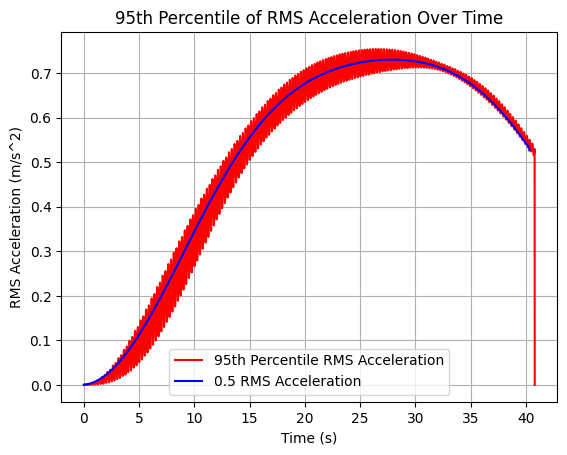

Maximum 0.5-second RMS value: 0.7301 m/s^2 at time 27.8400 s


In [40]:
# Output the 95th percentile of RMS acceleration at each time step
#print(f"95th Percentile of RMS Acceleration at each time step: {percentile_95_rms_at_each_timestep}")

# Plot the 95th percentile RMS acceleration over time
plt.plot(t, rms_acceleration_at_each_timestep, label="95th Percentile RMS Acceleration", color='r')
plt.plot(rms_time, rms_0_5s, label="0.5 RMS Acceleration", color='b')
plt.title("95th Percentile of RMS Acceleration Over Time")
plt.xlabel("Time (s)")
plt.ylabel("RMS Acceleration (m/s^2)")
plt.legend()
plt.grid(True)
plt.show()

# Find the maximum RMS value and its corresponding time
max_rms_value = np.max(rms_0_5s)
max_rms_time = rms_time[np.argmax(rms_0_5s)]

# Print the maximum RMS value and its corresponding time
print(f"Maximum 0.5-second RMS value: {max_rms_value:.4f} m/s^2 at time {max_rms_time:.4f} s")